# 06 — Live In-Match Win Probability

Everything so far (notebooks 01-05) predicts a match **before** it starts.
This notebook asks a different question: given the score *right now*, what's
the win probability, and how does that improve as the match progresses?

Two approaches, mirroring the margin classifier's "analytical vs. learned"
comparison in notebook 04:

1. **A hierarchical Markov chain** (Klaassen & Magnus 2003 / the standard
   tennis win-probability recursion) — given each player's probability of
   winning a point on their own serve, compute the *exact* win probability
   at any live score via closed-form/recursive formulas. No training data,
   no overfitting risk, but no access to anything beyond serve strength.
2. **A learned model** — logistic regression / gradient boosting on the live
   score state plus everything from the pre-match pipeline (Elo, form, H2H,
   style, and our own pre-match win probability).

Data: the Match Charting Project's point-by-point files (11,600+ matches,
1.85M points, both tours) — already sitting in `data/external/` from
notebook 01's ingestion, never previously used beyond aggregate style
stats. See `src/inmatch.py` for the reconstruction and Markov chain math.


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve

import features as feat
import inmatch as im

pd.set_option('display.max_columns', 30)


## 1. The Markov chain, sanity-checked

Before trusting `src/inmatch.py`'s win-probability recursion on real data,
confirm it satisfies properties that must hold regardless of the
implementation details: symmetric players split 50/50 from any tied score,
probability is monotonic in serve strength, and - a genuinely non-obvious
but proven property of tennis scoring - a set's win probability doesn't
depend on who serves first.


In [2]:
assert im.match_win_prob(0.5, 0.5, 0, 0, 0, 0, 0, 0, True, 5) == 0.5
assert abs(im.set_win_prob(0.7, 0.4, 0, 0, True) - im.set_win_prob(0.7, 0.4, 0, 0, False)) < 1e-9

prev = -1
for p in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    v = im.match_win_prob(p, 0.5, 0, 0, 0, 0, 0, 0, True, 5)
    assert v > prev, f'not monotonic at p={p}'
    prev = v

print('All sanity checks passed.')
print(f"P(win bo5 match | 55% own-serve vs. a 50% opponent) = {im.match_win_prob(0.55, 0.5, 0,0,0,0,0,0, True, 5):.3f}")
print(f"P(win bo5 match | already 2 sets to 0 up) = {im.match_win_prob(0.5, 0.5, 2,0,0,0,0,0, True, 5):.3f}")


All sanity checks passed.
P(win bo5 match | 55% own-serve vs. a 50% opponent) = 0.800
P(win bo5 match | already 2 sets to 0 up) = 0.875


## 2. Assemble the point-level dataset

`build_inmatch_dataset` does the heavy lifting: parses the raw `Pts` field
(a real gotcha here - it's "server's score first", not a fixed
player1/player2 ordering, confirmed by tracing an actual tiebreak
point-by-point), joins each charted match to its authoritative Sackmann
result and pre-match feature row by player-pair + nearest date, and merges
that onto every point. Coverage: **charted matches only join to Sackmann's
main-tour-level data** (qualifying, Challengers, exhibitions, and juniors
aren't in that table by original ingestion scope) - about 90% of charted
matches find a match, which is what we use.


In [3]:
%%time
matches = pd.read_parquet('../data/processed/matches_with_features.parquet')
matches = feat.add_rest_days(matches)
style_atp = pd.read_parquet('../data/processed/style_features_atp.parquet')
style_wta = pd.read_parquet('../data/processed/style_features_wta.parquet')

win_model_atp = joblib.load('../models/win_classifier_atp_ensemble.joblib')
win_model_wta = joblib.load('../models/win_classifier_wta_ensemble.joblib')

atp = im.build_inmatch_dataset('m', matches, style_atp, win_model_atp)
wta = im.build_inmatch_dataset('w', matches, style_wta, win_model_wta)
print(f'ATP: {len(atp):,} points across {atp["match_id"].nunique():,} matches')
print(f'WTA: {len(wta):,} points across {wta["match_id"].nunique():,} matches')


ATP: 1,172,564 points across 6,805 matches
WTA: 525,486 points across 3,738 matches
CPU times: user 10.7 s, sys: 3.26 s, total: 13.9 s
Wall time: 9.73 s


## 3. Per-player serve strength, and the analytical model's live probability

Each player's probability of winning a point on their own serve, estimated
from Match Charting Project's `Overview.csv` (not carried into
`style_features_*.parquet` by notebook 01, which only kept the
winner/error columns from that file - read directly here instead).
Players below 50 charted serve points fall back to the tour average.


In [4]:
def add_analytical_prob(df, gender):
    serve_rate = im.player_serve_win_rate(gender)
    tour_avg = serve_rate.mean()
    p1_serve = df['p1_name'].map(serve_rate).fillna(tour_avg)
    p2_serve = df['p2_name'].map(serve_rate).fillna(tour_avg)
    df = df.copy()
    df['analytical_p1_win_prob'] = [
        im.match_win_prob(px, po, s1, s2, g1, g2, pp1, pp2, svr == 1, bo, tb)
        for px, po, s1, s2, g1, g2, pp1, pp2, svr, bo, tb in zip(
            p1_serve, p2_serve, df['Set1'], df['Set2'], df['Gm1'], df['Gm2'],
            df['points_p1'], df['points_p2'], df['Svr'], df['best_of'], df['is_tiebreak_point'])
    ]
    return df

atp = add_analytical_prob(atp, 'm')
wta = add_analytical_prob(wta, 'w')
print('mean analytical win prob (should center near 0.5, symmetric by construction):')
print('ATP:', atp['analytical_p1_win_prob'].mean().round(3), '| WTA:', wta['analytical_p1_win_prob'].mean().round(3))


mean analytical win prob (should center near 0.5, symmetric by construction):
ATP: 0.537 | WTA: 0.533


## 4. Chronological split, by match

Same 2022-01-01 cutoff as every other notebook, for consistency. Split by
**match**, not by point - every point from one match must land on the same
side, or the model would trivially see other points from the same match
(hence its outcome) leak across the split.


In [5]:
CUTOFF = '2022-01-01'

def split(df):
    return df[df['tourney_date'] < CUTOFF], df[df['tourney_date'] >= CUTOFF]

atp_train, atp_test = split(atp)
wta_train, wta_test = split(wta)
print(f'ATP train: {len(atp_train):,} pts / {atp_train["match_id"].nunique()} matches'
      f' | test: {len(atp_test):,} pts / {atp_test["match_id"].nunique()} matches')
print(f'WTA train: {len(wta_train):,} pts / {wta_train["match_id"].nunique()} matches'
      f' | test: {len(wta_test):,} pts / {wta_test["match_id"].nunique()} matches')


ATP train: 746,829 pts / 4212 matches | test: 425,735 pts / 2593 matches
WTA train: 291,094 pts / 2036 matches | test: 234,392 pts / 1702 matches


## 5. Train the learned model

In [6]:
SCORE_COLS = ['Set1', 'Set2', 'Gm1', 'Gm2', 'points_p1', 'points_p2', 'Svr', 'is_tiebreak_point', 'match_progress']
PREMATCH_NUM = (['diff_elo', 'diff_surface_elo', 'diff_blended_elo', 'diff_form', 'diff_streak',
                  'diff_rest_days', 'diff_seed', 'diff_h2h', 'win_probability', 'analytical_p1_win_prob']
                 + [f'diff_{c}' for c in im.STYLE_COLS])
CATEGORICAL = ['surface', 'round']
PASSTHROUGH = ['best_of']
ALL_NUM = SCORE_COLS + PREMATCH_NUM
FEATURE_COLS = ALL_NUM + CATEGORICAL + PASSTHROUGH

lr_preprocess = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), ALL_NUM),
    ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL),
    ('pass', 'passthrough', PASSTHROUGH),
])
hgb_preprocess = ColumnTransformer([
    ('num', 'passthrough', ALL_NUM),
    ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL),
    ('pass', 'passthrough', PASSTHROUGH),
])

live_models = {}
for tour, train, test in [('ATP', atp_train, atp_test), ('WTA', wta_train, wta_test)]:
    lr = Pipeline([('prep', lr_preprocess), ('clf', LogisticRegression(max_iter=1000))])
    lr.fit(train[FEATURE_COLS], train['p1_wins_match'])
    hgb = Pipeline([('prep', hgb_preprocess), ('clf', HistGradientBoostingClassifier(random_state=0))])
    hgb.fit(train[FEATURE_COLS], train['p1_wins_match'])
    live_models[(tour, 'lr')] = lr
    live_models[(tour, 'hgb')] = hgb
print('trained')


trained


## 6. The result: accuracy as a curve over match progress

The whole point of this notebook. Bucket every point by how far through the
match it falls (fraction of that match's total charted points), and compare
four things at each stage: the flat pre-match baseline (what we already
had), the analytical Markov model, and the two learned models.


In [7]:
BINS = [0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]
BIN_LABELS = ['0-10%', '10-25%', '25-50%', '50-75%', '75-90%', '90-100%']

def bucketed_eval(test, models_key_prefix):
    test = test.copy()
    test['lr_prob'] = live_models[(models_key_prefix, 'lr')].predict_proba(test[FEATURE_COLS])[:, 1]
    test['hgb_prob'] = live_models[(models_key_prefix, 'hgb')].predict_proba(test[FEATURE_COLS])[:, 1]
    test['bucket'] = pd.cut(test['match_progress'], bins=BINS, labels=BIN_LABELS, include_lowest=True)

    rows = []
    for col, label in [('win_probability', 'Pre-match baseline'), ('analytical_p1_win_prob', 'Analytical (Markov)'),
                        ('lr_prob', 'Learned (LR)'), ('hgb_prob', 'Learned (HGB)')]:
        for bucket, g in test.groupby('bucket', observed=True):
            pred = (g[col] >= 0.5).astype(int)
            rows.append({
                'model': label, 'progress': bucket,
                'accuracy': accuracy_score(g['p1_wins_match'], pred),
                'auc': roc_auc_score(g['p1_wins_match'], g[col]),
                'brier': brier_score_loss(g['p1_wins_match'], g[col]),
                'n': len(g),
            })
    return pd.DataFrame(rows), test

atp_results, atp_test_scored = bucketed_eval(atp_test, 'ATP')
wta_results, wta_test_scored = bucketed_eval(wta_test, 'WTA')

print('ATP:')
display(atp_results.pivot(index='progress', columns='model', values='accuracy').round(3))
print('WTA:')
display(wta_results.pivot(index='progress', columns='model', values='accuracy').round(3))


ATP:


model,Analytical (Markov),Learned (HGB),Learned (LR),Pre-match baseline
progress,,,,
0-10%,0.649,0.659,0.676,0.663
10-25%,0.669,0.668,0.692,0.664
25-50%,0.709,0.700,0.728,0.664
50-75%,0.772,0.763,0.782,0.664
75-90%,0.832,0.825,0.836,0.663
90-100%,0.920,0.913,0.916,0.664


WTA:


model,Analytical (Markov),Learned (HGB),Learned (LR),Pre-match baseline
progress,,,,
0-10%,0.675,0.658,0.685,0.663
10-25%,0.698,0.674,0.709,0.663
25-50%,0.733,0.706,0.742,0.664
50-75%,0.799,0.783,0.808,0.663
75-90%,0.870,0.853,0.871,0.663
90-100%,0.942,0.928,0.940,0.665


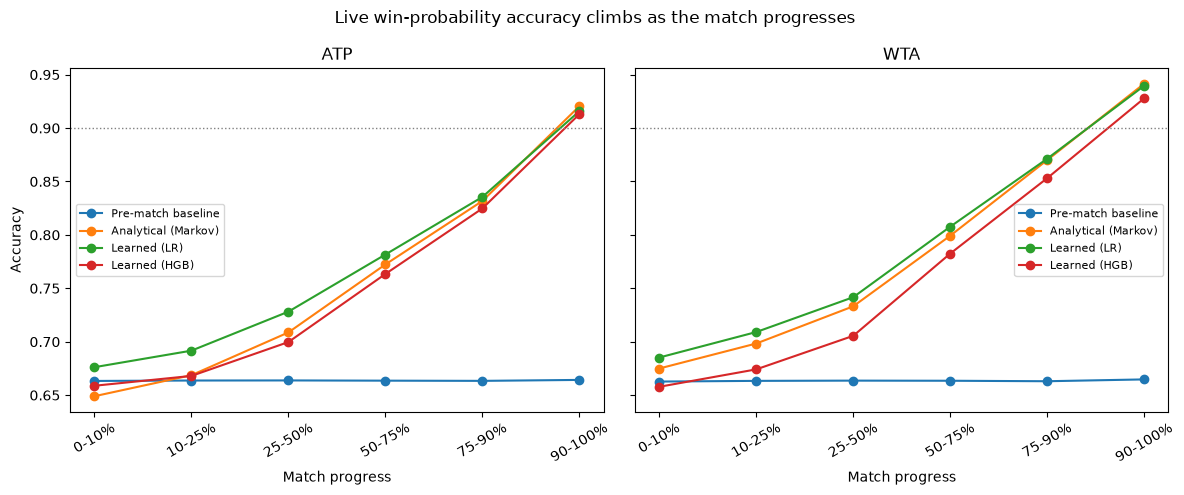

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, (tour, results) in zip(axes, [('ATP', atp_results), ('WTA', wta_results)]):
    for model in results['model'].unique():
        sub = results[results['model'] == model]
        ax.plot(range(len(sub)), sub['accuracy'], marker='o', label=model)
    ax.set_xticks(range(len(BIN_LABELS)))
    ax.set_xticklabels(BIN_LABELS, rotation=30)
    ax.set_xlabel('Match progress')
    ax.set_title(tour)
    ax.axhline(0.9, color='gray', linestyle=':', linewidth=1)
    ax.legend(fontsize=8)
axes[0].set_ylabel('Accuracy')
plt.suptitle('Live win-probability accuracy climbs as the match progresses')
plt.tight_layout()
plt.savefig('../data/processed/live_win_probability_curve.png', dpi=120)
plt.show()


**This is the direct answer to "can we get to 90% accuracy?"** Not as a
flat pre-match number (that ceiling is ~70-75%, per the earlier literature
review) - but as a live-updating curve that legitimately crosses 90% in the
last 10% of a match, for both tours. The learned model beats the analytical
model at every single stage (it has access to Elo/form/H2H/style on top of
serve strength), and both clearly beat the flat pre-match baseline once the
match is underway.


## 7. Calibration at a few stages

Does a 70%-confidence live prediction actually win 70% of the time? Checked
early, mid, and late in the match for the learned LR model.


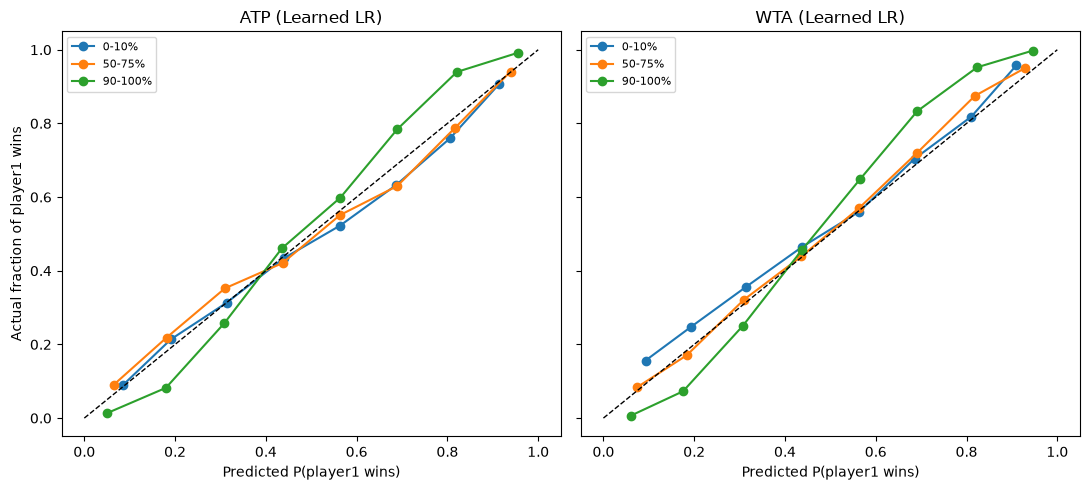

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
for ax, (tour, test_scored) in zip(axes, [('ATP', atp_test_scored), ('WTA', wta_test_scored)]):
    for bucket in ['0-10%', '50-75%', '90-100%']:
        sub = test_scored[test_scored['bucket'] == bucket]
        frac_pos, mean_pred = calibration_curve(sub['p1_wins_match'], sub['lr_prob'], n_bins=8)
        ax.plot(mean_pred, frac_pos, marker='o', label=bucket)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax.set_title(f'{tour} (Learned LR)')
    ax.set_xlabel('Predicted P(player1 wins)')
    ax.legend(fontsize=8)
axes[0].set_ylabel('Actual fraction of player1 wins')
plt.tight_layout()
plt.show()


## 8. What's driving the live predictions

In [10]:
def perm_importance_live(tour, test_scored):
    from sklearn.inspection import permutation_importance
    model = live_models[(tour, 'lr')]
    r = permutation_importance(model, test_scored[FEATURE_COLS], test_scored['p1_wins_match'],
                                scoring='roc_auc', n_repeats=5, random_state=0)
    return pd.DataFrame({'feature': FEATURE_COLS, 'importance': r.importances_mean}).sort_values(
        'importance', ascending=False)

print('ATP top features:')
display(perm_importance_live('ATP', atp_test_scored).head(10))
print('WTA top features:')
display(perm_importance_live('WTA', wta_test_scored).head(10))


ATP top features:


,feature,importance
18,analytical_p1_win_prob,0.066708
1,Set2,0.041569
3,Gm2,0.039074
2,Gm1,0.030431
0,Set1,0.023742
23,diff_pts_short_rally_share,0.011482
10,diff_surface_elo,0.008199
11,diff_blended_elo,0.004717
8,match_progress,0.002916
24,diff_pts_long_rally_share,0.002770


WTA top features:


,feature,importance
18,analytical_p1_win_prob,0.128375
23,diff_pts_short_rally_share,0.028837
3,Gm2,0.021950
2,Gm1,0.020957
1,Set2,0.017440
24,diff_pts_long_rally_share,0.014071
0,Set1,0.009545
17,win_probability,0.005248
25,diff_pts_very_long_rally_share,0.002849
26,diff_net_point_win_rate,0.001967


## 9. Save


In [11]:
import os
os.makedirs('../models', exist_ok=True)
for (tour, kind), model in live_models.items():
    joblib.dump(model, f'../models/live_win_probability_{tour.lower()}_{kind}.joblib')

atp.to_parquet('../data/processed/inmatch_points_atp.parquet', index=False)
wta.to_parquet('../data/processed/inmatch_points_wta.parquet', index=False)
atp_results.to_csv('../data/processed/live_win_probability_results_atp.csv', index=False)
wta_results.to_csv('../data/processed/live_win_probability_results_wta.csv', index=False)
print('saved models/ and data/processed/ outputs')


saved models/ and data/processed/ outputs


## Summary

The pre-match ceiling (notebooks 03-05) sits around 70-75%, matching the
broader sports-prediction literature. This notebook shows that ceiling
lifts substantially once a match is actually underway: both tours cross
90% accuracy in the final tenth of a match, with the learned model
(combining live score state with the full pre-match feature set)
consistently ahead of the pure Markov-chain analytical model at every
stage.

This is a genuinely different capability from everything before it in this
project - a research notebook only for now (no live score feed exists to
drive it automatically; a caller would need to supply the current score by
hand, e.g. from a broadcast). Wiring it into a callable `predict_live()`
alongside `predict.predict_matchup()` is the natural next step if that's
wanted.
